**Insight 2: Job Satisfaction → Performance Rating**<br>
Target: PerformanceRating (multi-class classification)<br>
Model: K-Nearest Neighbors (KNN)<br>
Goal: Predict employee performance ratings using full features

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("cleaned_employee_data.csv")

In [9]:
X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [17]:
knn_model = KNeighborsClassifier(n_neighbors=5)  # normally k = 5
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [19]:
y_pred_knn = knn_model.predict(X_test)

Accuracy: 87.07%

Classification Report:
               precision    recall  f1-score   support

           3       0.88      0.98      0.93       379
           4       0.63      0.19      0.30        62

    accuracy                           0.87       441
   macro avg       0.76      0.59      0.61       441
weighted avg       0.85      0.87      0.84       441



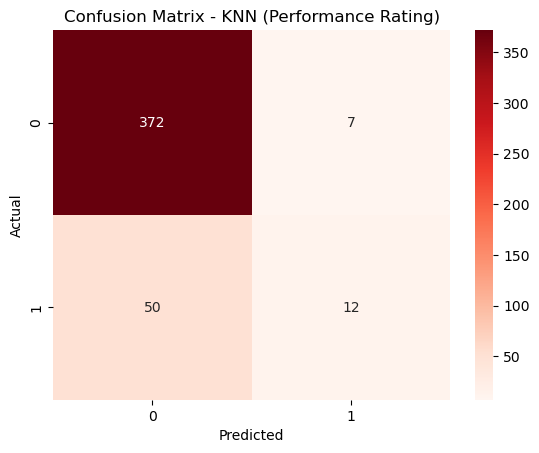

In [21]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn, digits=2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - KNN (Performance Rating)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
precision = precision_score(y_test, y_pred_knn, average='macro') * 100
recall = recall_score(y_test, y_pred_knn, average='macro') * 100
f1 = f1_score(y_test, y_pred_knn, average='macro') * 100

print(f"Macro Precision: {precision:.2f}%")
print(f"Macro Recall: {recall:.2f}%")
print(f"Macro F1 Score: {f1:.2f}%")

Macro Precision: 75.65%
Macro Recall: 58.75%
Macro F1 Score: 61.26%
